In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"C:\Users\Shraddha\Downloads\archive (38)\household_power_consumption.txt")

In [3]:
df.head()

,Date;Time;Global_active_power;Global_reactive_power;Voltage;Global_intensity;Sub_metering_1;Sub_metering_2;Sub_metering_3
0,16/12/2006;17:24:00;4.216;0.418;234.840;18.400...
1,16/12/2006;17:25:00;5.360;0.436;233.630;23.000...
2,16/12/2006;17:26:00;5.374;0.498;233.290;23.000...
3,16/12/2006;17:27:00;5.388;0.502;233.740;23.000...
4,16/12/2006;17:28:00;3.666;0.528;235.680;15.800...


In [4]:
df.tail()

,Date;Time;Global_active_power;Global_reactive_power;Voltage;Global_intensity;Sub_metering_1;Sub_metering_2;Sub_metering_3
2075254,26/11/2010;20:58:00;0.946;0.000;240.430;4.000;...
2075255,26/11/2010;20:59:00;0.944;0.000;240.000;4.000;...
2075256,26/11/2010;21:00:00;0.938;0.000;239.820;3.800;...
2075257,26/11/2010;21:01:00;0.934;0.000;239.700;3.800;...
2075258,26/11/2010;21:02:00;0.932;0.000;239.550;3.800;...


In [5]:
df = pd.read_csv(
    r"C:\Users\Shraddha\Downloads\archive (38)\household_power_consumption.txt",
    sep=";",
    na_values="?",
    low_memory=False
)

In [6]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [7]:
df.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

In [8]:
df.isna()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
2075254,False,False,False,False,False,False,False,False,False
2075255,False,False,False,False,False,False,False,False,False
2075256,False,False,False,False,False,False,False,False,False
2075257,False,False,False,False,False,False,False,False,False


In [9]:
df.isnull().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

<Axes: >

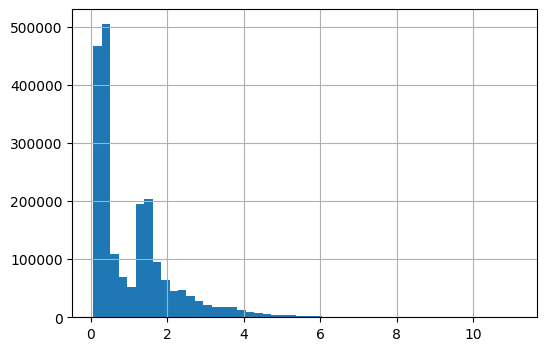

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
df["Global_active_power"].hist(bins=50)


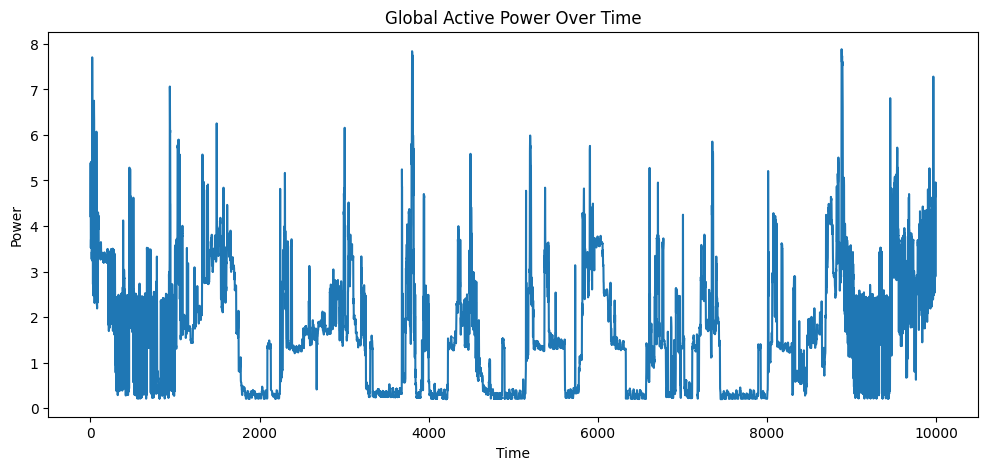

In [11]:
plt.figure(figsize=(12,5))
plt.plot(df["Global_active_power"][:10000])
plt.title("Global Active Power Over Time")
plt.xlabel("Time")
plt.ylabel("Power")
plt.show()

In [12]:
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S"
)

In [13]:
df.drop(["Date", "Time"], axis=1, inplace=True)
df.set_index("Datetime", inplace=True)

In [14]:
type(df.index)

pandas.core.indexes.datetimes.DatetimeIndex

In [15]:
type(df.index)

pandas.core.indexes.datetimes.DatetimeIndex

In [16]:
df["hour"] = df.index.hour

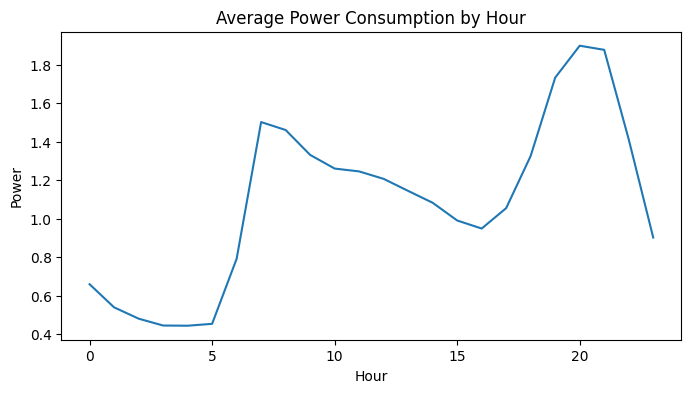

In [17]:
df.groupby("hour")["Global_active_power"].mean().plot(figsize=(8,4))
plt.title("Average Power Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("Power")
plt.show()

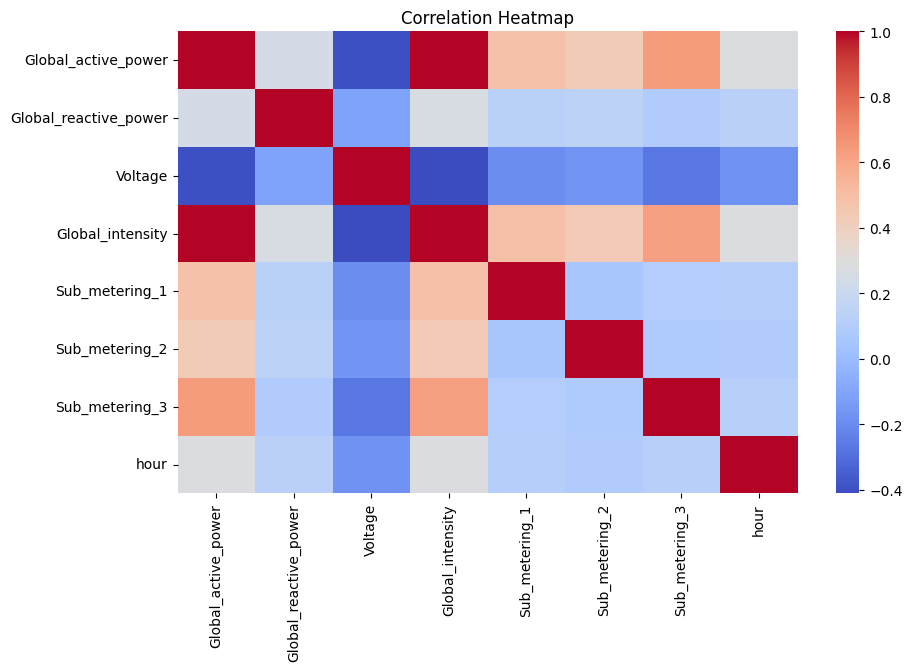

In [18]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [19]:
data = df[["Global_active_power"]]
data.head()

,Global_active_power
Datetime,
2006-12-16 17:24:00,4.216
2006-12-16 17:25:00,5.360
2006-12-16 17:26:00,5.374
2006-12-16 17:27:00,5.388
2006-12-16 17:28:00,3.666


In [20]:
for lag in range(1, 25):
    data[f"lag_{lag}"] = data["Global_active_power"].shift(lag)

data.dropna(inplace=True)

C:\Users\Shraddha\AppData\Local\Temp\ipykernel_23792\1769377061.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f"lag_{lag}"] = data["Global_active_power"].shift(lag)
C:\Users\Shraddha\AppData\Local\Temp\ipykernel_23792\1769377061.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f"lag_{lag}"] = data["Global_active_power"].shift(lag)
C:\Users\Shraddha\AppData\Local\Temp\ipykernel_23792\1769377061.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

In [21]:
train_size = int(len(data) * 0.8)
train = data.iloc[:train_size]
test = data.iloc[train_size:]

X_train = train.drop("Global_active_power", axis=1)
y_train = train["Global_active_power"]

X_test = test.drop("Global_active_power", axis=1)
y_test = test["Global_active_power"]

In [22]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, lr_preds)
rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

print("Linear Regression MAE:", mae)
print("Linear Regression RMSE:", rmse)

Linear Regression MAE: 0.08636350869021042
Linear Regression RMSE: 0.2206870981494139


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("Random Forest MAE:", mean_absolute_error(y_test, rf_preds))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, rf_preds)))

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU
from tensorflow.keras.callbacks import EarlyStopping

In [26]:
rnn = Sequential([SimpleRNN(50,activation='tanh',input_shape=(24,1)),
                  Dense(1)
                 ])
rnn.compile(optimizer='adam',loss='mse')
rnn.fit(X_train,y_train,epochs=10,batch_size=64,validation_split=0.1,callbacks=[EarlyStopping(patience=3)])

Epoch 1/10
23036/23036 [==============================] - 135s 6ms/step - loss: 0.0892 - val_loss: 0.0864
Epoch 2/10
23036/23036 [==============================] - 133s 6ms/step - loss: 0.0782 - val_loss: 0.0734
Epoch 3/10
23036/23036 [==============================] - 149s 6ms/step - loss: 0.0766 - val_loss: 0.0749
Epoch 4/10
23036/23036 [==============================] - 133s 6ms/step - loss: 0.0758 - val_loss: 0.0813
Epoch 5/10
23036/23036 [==============================] - 160s 7ms/step - loss: 0.0751 - val_loss: 0.0718
Epoch 6/10
23036/23036 [==============================] - 169s 7ms/step - loss: 0.0746 - val_loss: 0.0707
Epoch 7/10
23036/23036 [==============================] - 171s 7ms/step - loss: 0.0744 - val_loss: 0.0716
Epoch 8/10
23036/23036 [==============================] - 173s 7ms/step - loss: 0.0760 - val_loss: 0.0827
Epoch 9/10
23036/23036 [==============================] - 175s 8ms/step - loss: 0.0867 - val_loss: 0.0746


In [27]:
lstm = Sequential([
    LSTM(50, activation='tanh', input_shape=(24,1)),
    Dense(1)
])

lstm.compile(optimizer="adam", loss="mse")

lstm.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=3)]
)

Epoch 1/10
23036/23036 [==============================] - 440s 19ms/step - loss: 0.0878 - val_loss: 0.0692
Epoch 2/10
23036/23036 [==============================] - 487s 21ms/step - loss: 0.0735 - val_loss: 0.0690
Epoch 3/10
23036/23036 [==============================] - 470s 20ms/step - loss: 0.0714 - val_loss: 0.0677
Epoch 4/10
23036/23036 [==============================] - 482s 21ms/step - loss: 0.0692 - val_loss: 0.0647
Epoch 5/10
23036/23036 [==============================] - 512s 22ms/step - loss: 0.0664 - val_loss: 0.0651
Epoch 6/10
23036/23036 [==============================] - 534s 23ms/step - loss: 0.0646 - val_loss: 0.0618
Epoch 7/10
23036/23036 [==============================] - 640s 28ms/step - loss: 0.0634 - val_loss: 0.0607
Epoch 8/10
23036/23036 [==============================] - 681s 30ms/step - loss: 0.0625 - val_loss: 0.0603
Epoch 9/10
23036/23036 [==============================] - 678s 29ms/step - loss: 0.0618 - val_loss: 0.0603
Epoch 10/10
23036/23036 [============

In [28]:
gru = Sequential([
    GRU(50, activation='tanh', input_shape=(24,1)),
    Dense(1)
])

gru.compile(optimizer="adam", loss="mse")

gru.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=3)]
)

Epoch 1/10
23036/23036 [==============================] - 527s 23ms/step - loss: 0.0828 - val_loss: 0.0707
Epoch 2/10
23036/23036 [==============================] - 552s 24ms/step - loss: 0.0700 - val_loss: 0.0639
Epoch 3/10
23036/23036 [==============================] - 553s 24ms/step - loss: 0.0655 - val_loss: 0.0624
Epoch 4/10
23036/23036 [==============================] - 603s 26ms/step - loss: 0.0634 - val_loss: 0.0609
Epoch 5/10
23036/23036 [==============================] - 577s 25ms/step - loss: 0.0621 - val_loss: 0.0601
Epoch 6/10
23036/23036 [==============================] - 518s 23ms/step - loss: 0.0613 - val_loss: 0.0627
Epoch 7/10
23036/23036 [==============================] - 349s 15ms/step - loss: 0.0607 - val_loss: 0.0585
Epoch 8/10
23036/23036 [==============================] - 348s 15ms/step - loss: 0.0602 - val_loss: 0.0581
Epoch 9/10
23036/23036 [==============================] - 3085s 134ms/step - loss: 0.0599 - val_loss: 0.0583
Epoch 10/10
23036/23036 [==========

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(model, X_test, y_test):
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return mae, rmse

In [30]:
rnn_mae, rnn_rmse = evaluate(rnn, X_test, y_test)
lstm_mae, lstm_rmse = evaluate(lstm, X_test, y_test)
gru_mae, gru_rmse = evaluate(gru, X_test, y_test)

print("RNN  -> MAE:", rnn_mae, " RMSE:", rnn_rmse)
print("LSTM -> MAE:", lstm_mae," RMSE:", lstm_rmse)
print("GRU  -> MAE:", gru_mae, " RMSE:", gru_rmse)

12798/12798 [==============================] - 51s 4ms/step
RNN  -> MAE: 0.11538986298680458  RMSE: 0.23217393803771777
LSTM -> MAE: 0.07731319303762525  RMSE: 0.20315042979593145
GRU  -> MAE: 0.07313848720052071  RMSE: 0.20028283432022986
